## Figure Generation 

### Fig. 2 and Table II

In [31]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display


In [32]:
# Root-relative or absolute compare-output directories. These are the only two data inputs.
SAFETY_NAS_DATA_DIR: Path | str = "data/safety-nas/all-compare-map-seed0"
ACCURACY_NAS_DATA_DIR: Path | str = "data/accuracy-nas/compare-map-tp0"

In [33]:

def _notebook_dir() -> Path:
    if "__file__" in globals():
        return Path(__file__).resolve().parent

    vscode_notebook = globals().get("__vsc_ipynb_file__")
    if vscode_notebook:
        return Path(vscode_notebook).expanduser().resolve().parent

    cwd = Path.cwd().resolve()
    if (cwd / "visualizations" / "vis.ipynb").exists():
        return cwd / "visualizations"
    return cwd


NOTEBOOK_DIR = _notebook_dir()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "visualizations" else NOTEBOOK_DIR

def resolve_data_dir(path_like: Path | str) -> Path:
    raw_path = Path(path_like).expanduser()
    candidates = [raw_path] if raw_path.is_absolute() else [REPO_ROOT / raw_path, NOTEBOOK_DIR / raw_path]
    for candidate in candidates:
        candidate = candidate.resolve()
        has_nested_metrics = any(candidate.glob("*/metrics.jsonl"))
        has_flat_metrics = any(candidate.glob("*-metrics.jsonl")) or any(candidate.glob("*_metrics.jsonl"))
        if candidate.exists() and (has_nested_metrics or has_flat_metrics):
            return candidate
    tried = [candidate.resolve() for candidate in candidates]
    raise FileNotFoundError(
        f"No metrics.jsonl run directories found for {path_like!r}. Tried: {tried}"
    )


SAFETY_NAS_OUTPUT_DIR = resolve_data_dir(SAFETY_NAS_DATA_DIR)
ACCURACY_NAS_OUTPUT_DIR = resolve_data_dir(ACCURACY_NAS_DATA_DIR)

# Backward-compatible aliases used by the plotting helpers below.
BASE_OUTPUT_DIR = ACCURACY_NAS_OUTPUT_DIR
SECONDARY_BASE_OUTPUT_DIR = SAFETY_NAS_OUTPUT_DIR



BASELINE_LABEL = "Baseline"
SAFETY_NAS_LABEL = "Safety-NAS"
ACCURACY_NAS_LABEL = "Accuracy-NAS"
MODEL_GROUP_ORDER = [BASELINE_LABEL, SAFETY_NAS_LABEL, ACCURACY_NAS_LABEL]
MODEL_FAMILY_ORDER = [SAFETY_NAS_LABEL, ACCURACY_NAS_LABEL]


def model_family_for_run_dir(run_dir: Path) -> str:
    run_dir = resolve_compare_run_dir(run_dir)
    if run_dir.parent.resolve() == ACCURACY_NAS_OUTPUT_DIR.resolve():
        return ACCURACY_NAS_LABEL
    if run_dir.parent.resolve() == SAFETY_NAS_OUTPUT_DIR.resolve():
        return SAFETY_NAS_LABEL
    return run_dir.parent.name


def model_family_for_run_id(run_id: str) -> str:
    return model_family_for_run_dir(resolve_compare_run_dir(run_id))


def model_display_name(run_id: str) -> str:
    family = model_family_for_run_id(run_id)
    if family == SAFETY_NAS_LABEL:
        return f"{SAFETY_NAS_LABEL} ({TRAINED_MAP_LABELS.get(run_id, run_id)})" if "TRAINED_MAP_LABELS" in globals() else f"{SAFETY_NAS_LABEL} ({run_id})"
    if family == ACCURACY_NAS_LABEL:
        return ACCURACY_NAS_LABEL
    return run_id


def latest_run_dir(base_dir: Path = ACCURACY_NAS_OUTPUT_DIR) -> Path:
    candidates = sorted(
        [path for path in base_dir.glob("*/metrics.jsonl")],
        key=lambda p: p.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(
            f"No metrics.jsonl files found under {base_dir}. Run accuracy-nas/compare-track.py first."
        )
    return candidates[-1].parent

# Set this to a run directory name to pin one Accuracy-NAS comparison run.
RUN_DIR_OVERRIDE: Path | str | None = None


def resolve_run_dir() -> Path:
    if RUN_DIR_OVERRIDE:
        candidate = Path(RUN_DIR_OVERRIDE)
        if not candidate.is_absolute():
            candidate = ACCURACY_NAS_OUTPUT_DIR / candidate
        if candidate.is_file():
            candidate = candidate.parent
        if not candidate.exists():
            raise FileNotFoundError(
                f"Override directory {candidate} was not found. Update RUN_DIR_OVERRIDE."
            )
        metrics_file = candidate / "metrics.jsonl"
        if not metrics_file.exists():
            raise FileNotFoundError(
                f"{metrics_file} was not found; choose a directory containing metrics.jsonl."
            )
        return candidate
    return latest_run_dir()

RUN_DIR = resolve_run_dir()
METRICS_FILE = RUN_DIR / "metrics.jsonl"

with METRICS_FILE.open("r", encoding="utf-8") as fh:
    METRIC_RECORDS = [json.loads(line) for line in fh if line.strip()]

if not METRIC_RECORDS:
    raise RuntimeError(f"{METRICS_FILE} is empty; rerun compare-track.")

def display_map_name(map_name: str) -> str:
    return Path(map_name).name


rows: list[dict[str, object]] = []
for record in METRIC_RECORDS:
    map_name = record["map"]
    for run in record["runs"]:
        rows.append(
            {
                "map": map_name,
                "map_label": display_map_name(map_name),
                "arch": run["label"],
                "rmse": run.get("rmse"),
            }
        )

df = pd.DataFrame(rows)
pivot = df.pivot_table(index="arch", columns="map_label", values="rmse")
pivot = pivot.sort_index()

def default_highlight_arch(index: pd.Index) -> str | None:
    for candidate in (RUN_DIR.name, "arch7"):
        if candidate in index:
            return candidate
    return None


HIGHLIGHT_ARCH = default_highlight_arch(pivot.index)


### Metric Setup

In [34]:
metric_specs = {
    "crosstrack_rmse_m": {
        "title": "Cross-track RMSE",
        "ylabel": "Cross-track RMSE (m)",
        "table_title": "Cross-track RMSE (m)",
        "ylim_bottom": 0.0,
    },
    "crosstrack_mean_m": {
        "title": "Mean cross-track error",
        "ylabel": "Mean cross-track error (m)",
        "table_title": "Mean cross-track error (m)",
        "ylim_bottom": 0.0,
    },
    "crosstrack_std_m": {
        "title": "Cross-track variability",
        "ylabel": "Cross-track std (m)",
        "table_title": "Cross-track std (m)",
        "ylim_bottom": 0.0,
    },
    "crosstrack_max_m": {
        "title": "Maximum cross-track error",
        "ylabel": "Max cross-track error (m)",
        "table_title": "Max cross-track error (m)",
        "ylim_bottom": 0.0,
    },
    "heading_error_rmse_deg": {
        "title": "Heading-error RMSE",
        "ylabel": "Heading-error RMSE (deg)",
        "table_title": "Heading-error RMSE (deg)",
        "ylim_bottom": 0.0,
    },
    "heading_error_max_deg": {
        "title": "Maximum heading error",
        "ylabel": "Max heading error (deg)",
        "table_title": "Max heading error (deg)",
        "ylim_bottom": 0.0,
    },
    "wall_min_distance_m": {
        "title": "Minimum wall clearance",
        "ylabel": "Min wall distance (m)",
        "table_title": "Min wall distance (m)",
        "ylim_bottom": 0.0,
    },
    "wall_min_distance_risk": {
        "title": "Wall clearance risk",
        "ylabel": "Wall clearance risk (normalized)",
        "table_title": "Wall clearance risk (normalized)",
        "ylim_bottom": 0.0,
    },
    "steering_rate_mean_rad_s": {
        "title": "Mean steering-rate effort",
        "ylabel": "Mean steering rate (rad/s)",
        "table_title": "Mean steering rate (rad/s)",
        "ylim_bottom": 0.0,
    },
    "steering_rate_std_rad_s": {
        "title": "Steering-rate variability",
        "ylabel": "Steering-rate std (rad/s)",
        "table_title": "Steering-rate std (rad/s)",
        "ylim_bottom": 0.0,
    },
    "steering_rate_max_rad_s": {
        "title": "Maximum steering-rate spike",
        "ylabel": "Max steering rate (rad/s)",
        "table_title": "Max steering rate (rad/s)",
        "ylim_bottom": 0.0,
    },
    "speed_mean_m_s": {
        "title": "Mean speed",
        "ylabel": "Mean speed (m/s)",
        "table_title": "Mean speed (m/s)",
        "ylim_bottom": 0.0,
    },
    "speed_std_m_s": {
        "title": "Speed variability",
        "ylabel": "Speed std (m/s)",
        "table_title": "Speed std (m/s)",
        "ylim_bottom": 0.0,
    },
}


In [35]:

TRAINED_MAP_LABELS = {
    "arch7_yas_marina": "Yas Marina",
    "arch7_melbourne": "Melbourne",
    "arch7_sakhir": "Sakhir",
    "arch7_budapest": "Budapest",
    "arch7_sao_paulo": "Sao Paulo",
    "arch7_austin": "Austin",
    "arch7_zandvoort": "Zandvoort",
    "arch7_catalunya": "Catalunya",
    "arch7_brands_hatch": "Brands Hatch",
    "arch7_sepang": "Sepang",
}
def discover_compare_run_dirs(base_dir: Path = BASE_OUTPUT_DIR) -> list[Path]:
    output_dirs = [base_dir]
    if SECONDARY_BASE_OUTPUT_DIR:
        output_dirs.append(SECONDARY_BASE_OUTPUT_DIR)

    run_dirs: list[Path] = []
    for output_dir in output_dirs:
        run_dirs.extend(
            path.parent
            for path in sorted(output_dir.glob("*/metrics.jsonl"))
        )
        run_dirs.extend(sorted(output_dir.glob("*-metrics.jsonl")))
        run_dirs.extend(sorted(output_dir.glob("*_metrics.jsonl")))
    if not run_dirs:
        raise FileNotFoundError(f"No metrics.jsonl run directories found under {output_dirs}")
    return run_dirs


COMPARE_RUN_DIRS = discover_compare_run_dirs()
CROSS_RUN_AGG = "mean"


def resolve_compare_run_dir(path_like: str | Path) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        candidates = [BASE_OUTPUT_DIR / path]
        if SECONDARY_BASE_OUTPUT_DIR:
            candidates.append(SECONDARY_BASE_OUTPUT_DIR / path)
        path = next((candidate for candidate in candidates if candidate.exists()), candidates[0])
    metrics_path = path if path.is_file() else path / "metrics.jsonl"
    if not metrics_path.exists():
        raise FileNotFoundError(f"{metrics_path} does not exist")
    return path


def load_run_metric_rows(run_dir: Path, metric_key: str) -> pd.DataFrame:
    source_metric = "wall_min_distance_m" if metric_key == "wall_min_distance_risk" else metric_key
    metrics_path = run_dir if run_dir.is_file() else run_dir / "metrics.jsonl"
    rows: list[dict[str, object]] = []
    with metrics_path.open("r", encoding="utf-8") as fh:
        records = [json.loads(line) for line in fh if line.strip()]

    for record in records:
        for run in record["runs"]:
            raw_label = run["label"]
            is_arch7 = raw_label == run_dir.name or raw_label.startswith("arch7_")
            arch_label = "arch7" if is_arch7 else raw_label
            run_id = raw_label if raw_label.startswith("arch7_") else run_dir.name
            rows.append(
                {
                    "run_dir": run_id,
                    "model_source": model_family_for_run_dir(run_dir),
                    "map": record["map"],
                    "map_label": display_map_name(record["map"]),
                    "arch": arch_label,
                    "model_role": model_family_for_run_dir(run_dir) if arch_label == "arch7" else "Baseline",
                    "raw_label": raw_label,
                    "value": run.get(source_metric),
                }
            )
    return pd.DataFrame(rows)


def apply_derived_metric_transform(metric_df: pd.DataFrame, metric_key: str) -> pd.DataFrame:
    if metric_key != "wall_min_distance_risk":
        return metric_df
    metric_df = metric_df.copy()
    span = metric_df["value"].max() - metric_df["value"].min()
    if span == 0:
        metric_df["value"] = 0.5
    else:
        metric_df["value"] = 1.0 - ((metric_df["value"] - metric_df["value"].min()) / span)
    return metric_df


def aggregate_cross_run_metric(run_dirs: list[str | Path], metric_key: str) -> pd.DataFrame:
    frames = [load_run_metric_rows(resolve_compare_run_dir(run_dir), metric_key) for run_dir in run_dirs]
    metric_df = pd.concat(frames, ignore_index=True)
    metric_df["value"] = pd.to_numeric(metric_df["value"], errors="coerce")
    metric_df = metric_df.dropna(subset=["value"])
    metric_df = apply_derived_metric_transform(metric_df, metric_key)

    if CROSS_RUN_AGG == "mean":
        return metric_df.groupby(["run_dir", "arch"], as_index=False)["value"].mean()
    if CROSS_RUN_AGG == "median":
        return metric_df.groupby(["run_dir", "arch"], as_index=False)["value"].median()
    raise ValueError(f"Unsupported CROSS_RUN_AGG={CROSS_RUN_AGG!r}")


### Three-Way Comparison Setup


In [36]:
BASELINE_ARCHES = [
    "arch1", "arch2", "arch3", "arch4", "arch5", "arch6",
]
BASELINE_ARCH_LABEL = ", ".join(BASELINE_ARCHES)
SAFETY_NAS_ARCH = "arch7"
ACCURACY_NAS_ARCH = "arch7"

COMPOSITE_RUN_DIRS = list(COMPARE_RUN_DIRS)
RESOLVED_COMPOSITE_RUN_DIRS = [resolve_compare_run_dir(run_dir) for run_dir in COMPOSITE_RUN_DIRS]
SAFETY_NAS_COMPARE_DIR = SECONDARY_BASE_OUTPUT_DIR.resolve() if SECONDARY_BASE_OUTPUT_DIR else None
ACCURACY_NAS_COMPARE_DIR = BASE_OUTPUT_DIR.resolve()

BASELINE_RUN_DIRS = [
    run_dir for run_dir in RESOLVED_COMPOSITE_RUN_DIRS
    if SAFETY_NAS_COMPARE_DIR and run_dir.parent.resolve() == SAFETY_NAS_COMPARE_DIR
]
SAFETY_NAS_RUN_DIRS = BASELINE_RUN_DIRS
ACCURACY_NAS_RUN_DIRS = [
    run_dir for run_dir in RESOLVED_COMPOSITE_RUN_DIRS
    if run_dir.parent.resolve() == ACCURACY_NAS_COMPARE_DIR
]


EVALUATED_METRICS = [
    "crosstrack_max_m",
    "heading_error_max_deg",
    "wall_min_distance_risk",
]

# All possible
# EVALUATED_METRICS = [
#     "crosstrack_rmse_m",
#     "crosstrack_mean_m",
#     "crosstrack_std_m",
#     "crosstrack_max_m",
#     "heading_error_rmse_deg",
#     "heading_error_max_deg",
#     "wall_min_distance_risk",
#     "steering_rate_mean_rad_s",
#     "steering_rate_std_rad_s",
#     "steering_rate_max_rad_s",
#     "speed_mean_m_s",
#     "speed_std_m_s",
# ]

SAFETY_MINIMIZE_METRICS = EVALUATED_METRICS
SELECTED_IMPROVEMENT_METRICS = EVALUATED_METRICS


def normalize_metric(series: pd.Series) -> pd.Series:
    span = series.max() - series.min()
    if span == 0:
        return pd.Series(0.5, index=series.index)
    return (series - series.min()) / span


def load_metric_rows_without_transform(run_dir: Path, metric_key: str) -> pd.DataFrame:
    source_metric = "wall_min_distance_m" if metric_key == "wall_min_distance_risk" else metric_key
    return load_run_metric_rows(run_dir, source_metric)


def apply_comparison_metric_transform(metric_df: pd.DataFrame, metric_key: str) -> pd.DataFrame:
    metric_df = metric_df.copy()
    if metric_key == "wall_min_distance_risk":
        span = metric_df["value"].max() - metric_df["value"].min()
        if span == 0:
            metric_df["value"] = 0.5
        else:
            metric_df["value"] = 1.0 - ((metric_df["value"] - metric_df["value"].min()) / span)
    return metric_df


def comparison_metric_values(metric_keys: list[str]) -> pd.DataFrame:
    frames = []
    for metric_key in metric_keys:
        metric_frames = []

        baseline_frames = []
        for run_dir in BASELINE_RUN_DIRS:
            run_df = load_metric_rows_without_transform(run_dir, metric_key)
            run_df = run_df[run_df["arch"].isin(BASELINE_ARCHES)].copy()
            baseline_frames.append(run_df)
        if baseline_frames:
            baseline_df = pd.concat(baseline_frames, ignore_index=True)
            baseline_df["value"] = pd.to_numeric(baseline_df["value"], errors="coerce")
            baseline_df = (
                baseline_df.groupby(
                    ["map", "map_label", "arch", "model_role", "raw_label"],
                    as_index=False,
                )["value"]
                .mean()
            )
            baseline_df["run_dir"] = "baseline_mean"
            baseline_df["model_source"] = BASELINE_LABEL
            baseline_df["model_group"] = BASELINE_LABEL
            metric_frames.append(baseline_df)

        for run_dir in SAFETY_NAS_RUN_DIRS:
            run_df = load_metric_rows_without_transform(run_dir, metric_key)
            run_df = run_df[run_df["arch"] == SAFETY_NAS_ARCH].copy()
            run_df["model_group"] = SAFETY_NAS_LABEL
            metric_frames.append(run_df)

        for run_dir in ACCURACY_NAS_RUN_DIRS:
            run_df = load_metric_rows_without_transform(run_dir, metric_key)
            run_df = run_df[run_df["arch"] == ACCURACY_NAS_ARCH].copy()
            run_df["model_group"] = ACCURACY_NAS_LABEL
            metric_frames.append(run_df)

        metric_df = pd.concat(metric_frames, ignore_index=True)
        metric_df["value"] = pd.to_numeric(metric_df["value"], errors="coerce")
        metric_df = metric_df.dropna(subset=["value"])
        metric_df = apply_comparison_metric_transform(metric_df, metric_key)
        metric_df["metric"] = metric_key
        metric_df["metric_label"] = metric_specs.get(metric_key, {}).get("ylabel", metric_key)
        metric_df["normalized_value"] = normalize_metric(metric_df["value"])
        frames.append(metric_df)

    return pd.concat(frames, ignore_index=True)


def percent_lower_than(reference: float, candidate: float) -> float:
    if pd.isna(reference) or pd.isna(candidate) or reference == 0:
        return np.nan
    return 100.0 * (reference - candidate) / reference


def summarize_distribution(series: pd.Series) -> pd.Series:
    return pd.Series(
        {
            "mean_score": series.mean(),
            "median_score": series.median(),
            "min_score": series.min(),
            "max_score": series.max(),
            "n_values": series.count(),
        }
    )


def comparison_summary(metric_df: pd.DataFrame, value_col: str = "normalized_value") -> pd.DataFrame:
    summary = (
        metric_df.groupby("model_group")[value_col]
        .apply(summarize_distribution)
        .unstack()
        .reindex(MODEL_GROUP_ORDER)
    )
    baseline = summary.loc[BASELINE_LABEL]
    rows = []
    for model_group in [SAFETY_NAS_LABEL, ACCURACY_NAS_LABEL]:
        candidate = summary.loc[model_group]
        rows.append(
            {
                "model_group": model_group,
                "candidate_mean_score": candidate["mean_score"],
                "baseline_mean_score": baseline["mean_score"],
                "candidate_vs_baseline_mean_%": percent_lower_than(baseline["mean_score"], candidate["mean_score"]),
                "n_candidate_values": candidate["n_values"],
                "n_baseline_values": baseline["n_values"],
            }
        )
    return pd.DataFrame(rows)


def format_comparison_table(df: pd.DataFrame):
    return df.style.format(
        {
            "candidate_mean_score": "{:.3f}",
            "baseline_mean_score": "{:.3f}",
            "candidate_vs_baseline_mean_%": "{:+.3f}%",
            "n_candidate_values": "{:.0f}",
            "n_baseline_values": "{:.0f}",
        }
    )


In [37]:
# Shared labels and colors for the box plot and mean/SD table.
COMPONENT_IMPROVEMENT_METRICS = EVALUATED_METRICS
component_metric_labels = {
    metric_key: metric_specs.get(metric_key, {}).get("ylabel", metric_key)
    for metric_key in COMPONENT_IMPROVEMENT_METRICS
}
component_order = [component_metric_labels[metric_key] for metric_key in COMPONENT_IMPROVEMENT_METRICS]
model_group_column_colors = {
    BASELINE_LABEL: "#e5e7eb",
    ACCURACY_NAS_LABEL: "#ede9fe",
    SAFETY_NAS_LABEL: "#dbeafe",
}


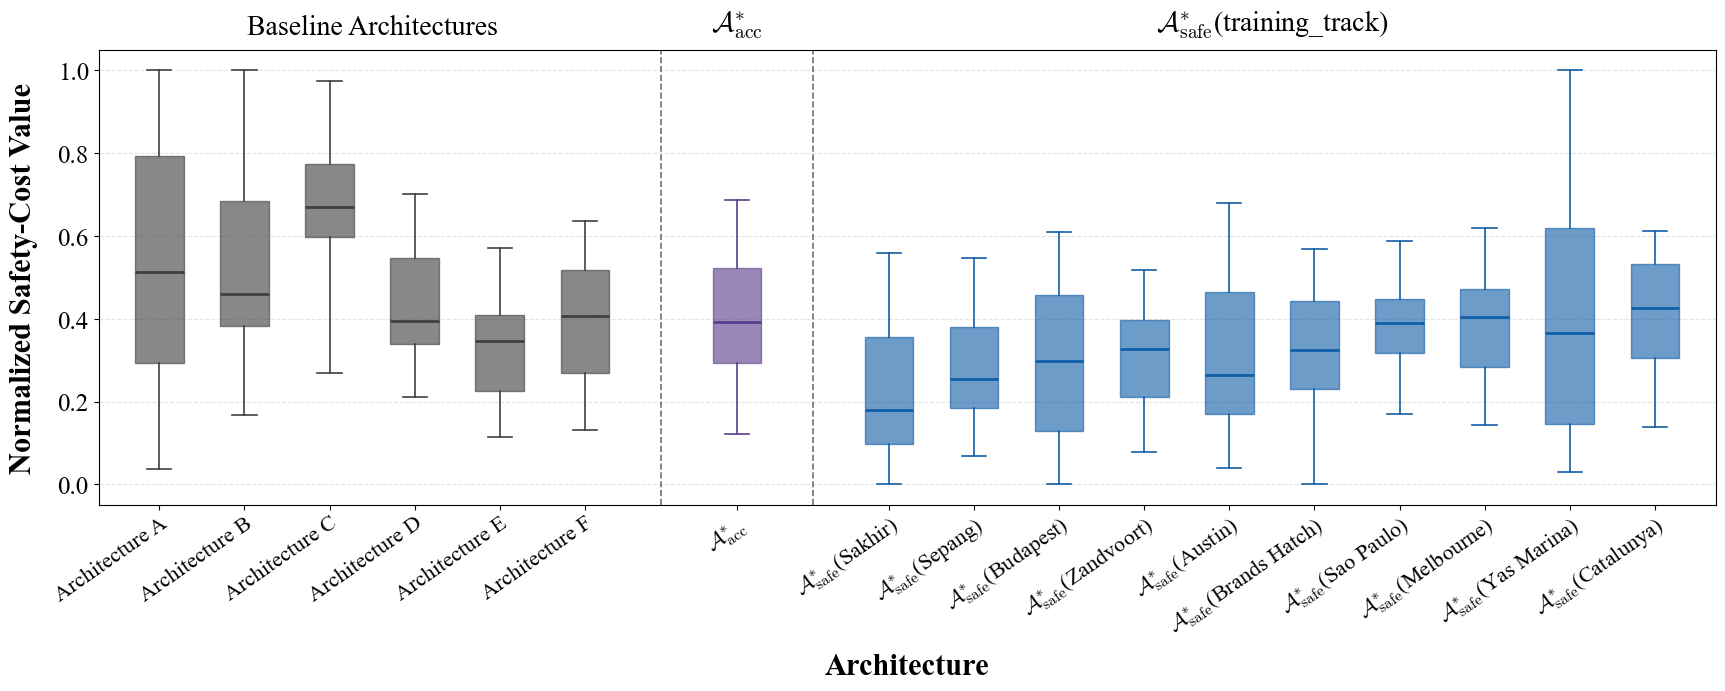

In [38]:
# Six-map analysis
# Plot layout controls (edit these first).
# Smaller/negative values move the rotated X tick labels upward toward the axis.
X_TICK_LABEL_PAD = 2
# Physical height of the graph/Y axis in inches.
PLOT_HEIGHT_INCHES = 6.8


def comparison_metric_values_six_maps(metric_keys: list[str]) -> pd.DataFrame:
    frames = []
    for metric_key in metric_keys:
        metric_frames = []

        baseline_frames = []
        for run_dir in BASELINE_RUN_DIRS:
            run_df = load_metric_rows_without_transform(run_dir, metric_key)
            run_df = run_df[run_df["arch"].isin(BASELINE_ARCHES)].copy()
            baseline_frames.append(run_df)
        if baseline_frames:
            baseline_df = pd.concat(baseline_frames, ignore_index=True)
            baseline_df["value"] = pd.to_numeric(baseline_df["value"], errors="coerce")
            baseline_df = (
                baseline_df.groupby(
                    ["map", "map_label", "arch", "model_role", "raw_label"],
                    as_index=False,
                )["value"]
                .mean()
            )
            baseline_df["run_dir"] = "baseline_mean"
            baseline_df["model_source"] = BASELINE_LABEL
            baseline_df["model_group"] = BASELINE_LABEL
            metric_frames.append(baseline_df)

        for run_dir in SAFETY_NAS_RUN_DIRS:
            run_df = load_metric_rows_without_transform(run_dir, metric_key)
            run_df = run_df[run_df["arch"] == SAFETY_NAS_ARCH].copy()
            run_df["model_group"] = SAFETY_NAS_LABEL
            metric_frames.append(run_df)

        for run_dir in ACCURACY_NAS_RUN_DIRS:
            run_df = load_metric_rows_without_transform(run_dir, metric_key)
            run_df = run_df[run_df["arch"] == ACCURACY_NAS_ARCH].copy()
            run_df["model_group"] = ACCURACY_NAS_LABEL
            metric_frames.append(run_df)

        metric_df = pd.concat(metric_frames, ignore_index=True)
        metric_df["value"] = pd.to_numeric(metric_df["value"], errors="coerce")
        metric_df = metric_df.dropna(subset=["value"])
        metric_df = apply_comparison_metric_transform(metric_df, metric_key)
        metric_df["metric"] = metric_key
        metric_df["metric_label"] = metric_specs.get(metric_key, {}).get("ylabel", metric_key)
        metric_df["normalized_value"] = normalize_metric(metric_df["value"])
        frames.append(metric_df)

    return pd.concat(frames, ignore_index=True)


def add_box_label_columns(metric_df: pd.DataFrame) -> pd.DataFrame:
    metric_df = metric_df.copy()
    metric_df["box_label"] = metric_df["arch"]
    metric_df.loc[metric_df["model_group"] == ACCURACY_NAS_LABEL, "box_label"] = ACCURACY_NAS_LABEL
    metric_df.loc[metric_df["model_group"] == SAFETY_NAS_LABEL, "box_label"] = metric_df["run_dir"]
    return metric_df


def safety_run_labels_by_mean(metric_df: pd.DataFrame) -> list[str]:
    safety_means = (
        metric_df.loc[metric_df["model_group"] == SAFETY_NAS_LABEL]
        .groupby("run_dir", as_index=False)["normalized_value"]
        .mean()
        .rename(columns={"normalized_value": "mean_normalized_value"})
    )
    safety_means["track_label"] = safety_means["run_dir"].map(
        lambda run_id: TRAINED_MAP_LABELS.get(run_id, run_id)
    )
    return safety_means.sort_values(
        ["mean_normalized_value", "track_label"],
        ascending=[True, True],
    )["run_dir"].tolist()


def plot_six_map_composite_boxplot(metric_df: pd.DataFrame) -> None:
    plt.rcParams.update(
        {
            "font.family": "serif",
            "font.serif": ["Computer Modern Roman", "Latin Modern Roman", "Times New Roman", "Times"],
            "font.size": 18,
            "axes.labelsize": 20,
            "axes.titlesize": 20,
            "xtick.labelsize": 14,
            "ytick.labelsize": 18,
            "mathtext.fontset": "cm",
        }
    )
    baseline_arches = [arch for arch in BASELINE_ARCHES if arch in set(metric_df["arch"])]
    safety_run_labels = safety_run_labels_by_mean(metric_df)
    accuracy_values = metric_df.loc[
        metric_df["model_group"] == ACCURACY_NAS_LABEL,
        "normalized_value",
    ].dropna().to_numpy()

    baseline_display_labels = {
        arch: f"Architecture {chr(ord('A') + idx)}"
        for idx, arch in enumerate(baseline_arches)
    }
    accuracy_display_label = r"$\mathcal{A}_{\mathrm{acc}}^{*}$"
    safety_display_labels = {
        run_label: rf"$\mathcal{{A}}_{{\mathrm{{safe}}}}^{{*}}$({TRAINED_MAP_LABELS.get(run_label, run_label)})"
        for run_label in safety_run_labels
    }

    box_width = 0.40
    edge_gap = 0.30
    group_gap = 0.85
    box_step = box_width + edge_gap
    baseline_positions = np.arange(len(baseline_arches), dtype=float) * box_step
    accuracy_position = baseline_positions[-1] + box_width / 2 + group_gap + box_width / 2
    safety_start = accuracy_position + box_width / 2 + group_gap + box_width / 2
    safety_positions = safety_start + np.arange(len(safety_run_labels), dtype=float) * box_step
    baseline_position_lookup = dict(zip(baseline_arches, baseline_positions))
    safety_position_lookup = dict(zip(safety_run_labels, safety_positions))

    n_boxes = len(baseline_arches) + (1 if accuracy_values.size else 0) + len(safety_run_labels)
    fig_width = max(14, 0.82 * max(n_boxes, 1) + 3.2)
    fig, ax = plt.subplots(figsize=(fig_width, PLOT_HEIGHT_INCHES), constrained_layout=True)

    baseline_color = plt.cm.Greys(0.80)
    accuracy_color = "#5b3f8c"
    safety_color = plt.cm.Blues(0.82)

    def draw_box(values: np.ndarray, position: float, color) -> None:
        if values.size == 0:
            return
        ax.boxplot(
            [values],
            positions=[position],
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            whis=(0, 100),
            showfliers=False,
            boxprops={"facecolor": color, "edgecolor": color, "alpha": 0.62},
            medianprops={"color": color, "linewidth": 2.0},
            whiskerprops={"color": color, "linewidth": 1.2},
            capprops={"color": color, "linewidth": 1.2},
        )

    for arch in baseline_arches:
        values = metric_df.loc[
            (metric_df["model_group"] == BASELINE_LABEL) & (metric_df["arch"] == arch),
            "normalized_value",
        ].dropna().to_numpy()
        draw_box(values, baseline_position_lookup[arch], baseline_color)
    if accuracy_values.size:
        draw_box(accuracy_values, accuracy_position, accuracy_color)
    for run_label in safety_run_labels:
        values = metric_df.loc[
            (metric_df["model_group"] == SAFETY_NAS_LABEL)
            & (metric_df["run_dir"] == run_label),
            "normalized_value",
        ].dropna().to_numpy()
        draw_box(values, safety_position_lookup[run_label], safety_color)

    separator_positions = []
    if len(baseline_positions) and accuracy_values.size:
        separator_positions.append((baseline_positions[-1] + accuracy_position) / 2)
    if accuracy_values.size and len(safety_positions):
        separator_positions.append((accuracy_position + safety_positions[0]) / 2)
    for separator_x in separator_positions:
        ax.axvline(separator_x, color="0.25", linewidth=1.2, linestyle="--", alpha=0.75)

    if len(baseline_positions):
        ax.text(baseline_positions.mean(), 1.02, "Baseline Architectures", transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=20)
    if accuracy_values.size:
        ax.text(accuracy_position, 1.02, accuracy_display_label, transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=20, color="black")
    if len(safety_positions):
        ax.text(safety_positions.mean(), 1.02, r"$\mathcal{A}_{\mathrm{safe}}^{*}$(training_track)", transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=20, color="black")

    tick_positions = [baseline_position_lookup[arch] for arch in baseline_arches]
    tick_labels = [baseline_display_labels[arch] for arch in baseline_arches]
    if accuracy_values.size:
        tick_positions.append(accuracy_position)
        tick_labels.append(accuracy_display_label)
    tick_positions.extend([safety_position_lookup[run_label] for run_label in safety_run_labels])
    tick_labels.extend([safety_display_labels[run_label] for run_label in safety_run_labels])
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=35, ha="right", rotation_mode="anchor")
    ax.tick_params(axis="x", labelsize=16, pad=X_TICK_LABEL_PAD)
    ax.tick_params(axis="y", labelsize=18)
    ax.set_ylabel("Normalized Safety-Cost Value", fontsize=22, fontweight="bold", labelpad=14)
    ax.set_xlabel("Architecture", fontsize=22, fontweight="bold", labelpad=10)
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.set_ylim(-.05, 1.05)
    ax.set_yticks(np.linspace(0, 1, 6))
    all_positions = np.array(tick_positions, dtype=float)
    if all_positions.size:
        ax.set_xlim(all_positions.min() - box_width / 2 - edge_gap, all_positions.max() + box_width / 2 + edge_gap)

six_map_values = comparison_metric_values_six_maps(EVALUATED_METRICS)
six_map_component_values = six_map_values.copy()
six_map_component_values["component"] = six_map_component_values["metric"].map(component_metric_labels)

plot_six_map_composite_boxplot(six_map_values)


### Six-Map Mean and Sample Standard Deviation

Each row summarizes one model across the six evaluation maps. Lower normalized safety-cost values are better.


In [39]:
mean_sd_source = six_map_component_values.copy()

baseline_labels = {
    arch: f"Baseline {chr(ord("A") + idx)}"
    for idx, arch in enumerate(BASELINE_ARCHES)
}
mean_sd_source["model"] = mean_sd_source["arch"]
baseline_mask = mean_sd_source["model_group"] == BASELINE_LABEL
accuracy_mask = mean_sd_source["model_group"] == ACCURACY_NAS_LABEL
safety_mask = mean_sd_source["model_group"] == SAFETY_NAS_LABEL
mean_sd_source.loc[baseline_mask, "model"] = mean_sd_source.loc[baseline_mask, "arch"].map(baseline_labels)
mean_sd_source.loc[accuracy_mask, "model"] = "Accuracy-NAS Mean"
mean_sd_source.loc[safety_mask, "model"] = mean_sd_source.loc[safety_mask, "run_dir"].map(
    lambda run_id: f"Safety-NAS ({TRAINED_MAP_LABELS.get(run_id, run_id)})"
)

individual_summary = (
    mean_sd_source.loc[baseline_mask | safety_mask]
    .groupby(["model_group", "model", "component"], as_index=False)
    .agg(mean=("normalized_value", "mean"), sample_sd=("normalized_value", "std"))
)

summary_labels = {
    BASELINE_LABEL: "Baseline Mean",
    ACCURACY_NAS_LABEL: "Accuracy-NAS Mean",
    SAFETY_NAS_LABEL: "Safety-NAS Mean",
}
pooled_summary = (
    mean_sd_source.groupby(["model_group", "component"], as_index=False)
    .agg(mean=("normalized_value", "mean"), sample_sd=("normalized_value", "std"))
)
pooled_summary["model"] = pooled_summary["model_group"].map(summary_labels)

summary_long = pd.concat([individual_summary, pooled_summary], ignore_index=True)
mean_sd_table = summary_long.pivot(
    index=["model_group", "model"],
    columns="component",
    values=["mean", "sample_sd"],
).swaplevel(0, 1, axis=1)
ordered_columns = pd.MultiIndex.from_tuples([
    (component, statistic)
    for component in component_order
    for statistic in ("Mean", "Std")
])
mean_sd_table.columns = pd.MultiIndex.from_tuples([
    (component, "Mean" if statistic == "mean" else "Std")
    for component, statistic in mean_sd_table.columns
])
mean_sd_table = mean_sd_table.reindex(columns=ordered_columns)

row_order = (
    list(baseline_labels.values())
    + ["Baseline Mean", "Accuracy-NAS Mean"]
    + sorted(mean_sd_source.loc[safety_mask, "model"].dropna().unique())
    + ["Safety-NAS Mean"]
)
mean_sd_table = mean_sd_table.reset_index().set_index("model").reindex(row_order)
mean_sd_groups = mean_sd_table.pop("model_group")

baseline_values = mean_sd_table.loc["Baseline Mean"]
reduction_rows = []
for candidate_label, reduction_label, group in [
    ("Accuracy-NAS Mean", "Accuracy-NAS Reduction (%)", ACCURACY_NAS_LABEL),
    ("Safety-NAS Mean", "Safety-NAS Reduction (%)", SAFETY_NAS_LABEL),
]:
    reduction = 100.0 * (baseline_values - mean_sd_table.loc[candidate_label]) / baseline_values
    reduction.name = reduction_label
    reduction_rows.append(reduction)
    mean_sd_groups.loc[reduction_label] = group
mean_sd_table = pd.concat([mean_sd_table, pd.DataFrame(reduction_rows)])
mean_sd_table.index.name = "Architecture"

formatted_table = mean_sd_table.copy().astype(object)
for row_label in formatted_table.index:
    is_reduction = row_label.endswith("Reduction (%)")
    for column in formatted_table.columns:
        value = mean_sd_table.loc[row_label, column]
        formatted_table.loc[row_label, column] = f"{value:.1f}%" if is_reduction else f"{value:.3f}"

def color_summary_rows(row: pd.Series) -> list[str]:
    group = mean_sd_groups.loc[row.name]
    color = model_group_column_colors.get(group, "#ffffff")
    weight = "font-weight: bold; " if "Mean" in row.name or "Reduction" in row.name else ""
    return [f"{weight}background-color: {color}" for _ in row]

display(formatted_table.style.apply(color_summary_rows, axis=1))
